In [23]:
import pickle 
import numpy as np
muq_path = '/home/zhangyk/zhouyz/rec/recbole_v2/dataset/m4a/m4a-muq.pkl'
muq = pickle.load(open(muq_path, 'rb'))

In [24]:
muq_list = list(muq.values())
muq_array = np.array(muq_list)

使用快速相关性计算...


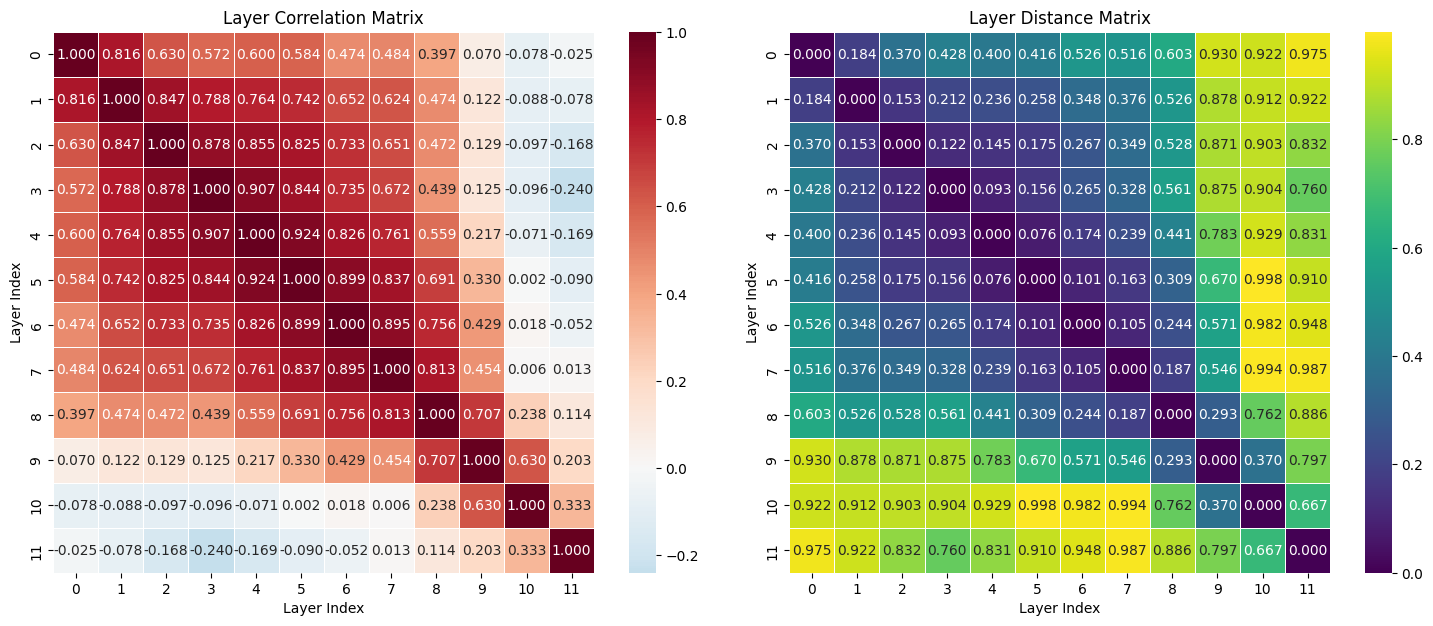

In [25]:
# 优化版本2: 使用相关性矩阵作为快速近似
import matplotlib.pyplot as plt
import seaborn as sns
def calculate_correlation_matrix_fast(data):
    """
    使用相关性矩阵作为层间关系的快速近似
    """
    N, L, H = data.shape
    
    # 计算每层的平均表示
    layer_means = np.mean(data, axis=2)  # Shape: (N, L)
    
    # 计算层间相关性矩阵
    correlation_matrix = np.corrcoef(layer_means.T)
    
    # 转换为"距离"矩阵 (1 - |correlation|)
    distance_matrix = 1 - np.abs(correlation_matrix)
    
    return correlation_matrix, distance_matrix

print("使用快速相关性计算...")
corr_matrix, dist_matrix = calculate_correlation_matrix_fast(muq_array)

# 绘制相关性热力图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 相关性矩阵
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            fmt='.3f',
            square=True,
            linewidths=0.5,
            center=0,
            ax=ax1)
ax1.set_title('Layer Correlation Matrix')
ax1.set_xlabel('Layer Index')
ax1.set_ylabel('Layer Index')

# 距离矩阵
sns.heatmap(dist_matrix, 
            annot=True, 
            cmap='viridis', 
            fmt='.3f',
            square=True,
            linewidths=0.5,
            ax=ax2)
ax2.set_title('Layer Distance Matrix')
ax2.set_xlabel('Layer Index')
ax2.set_ylabel('Layer Index')

plt.tight_layout()
plt.show()

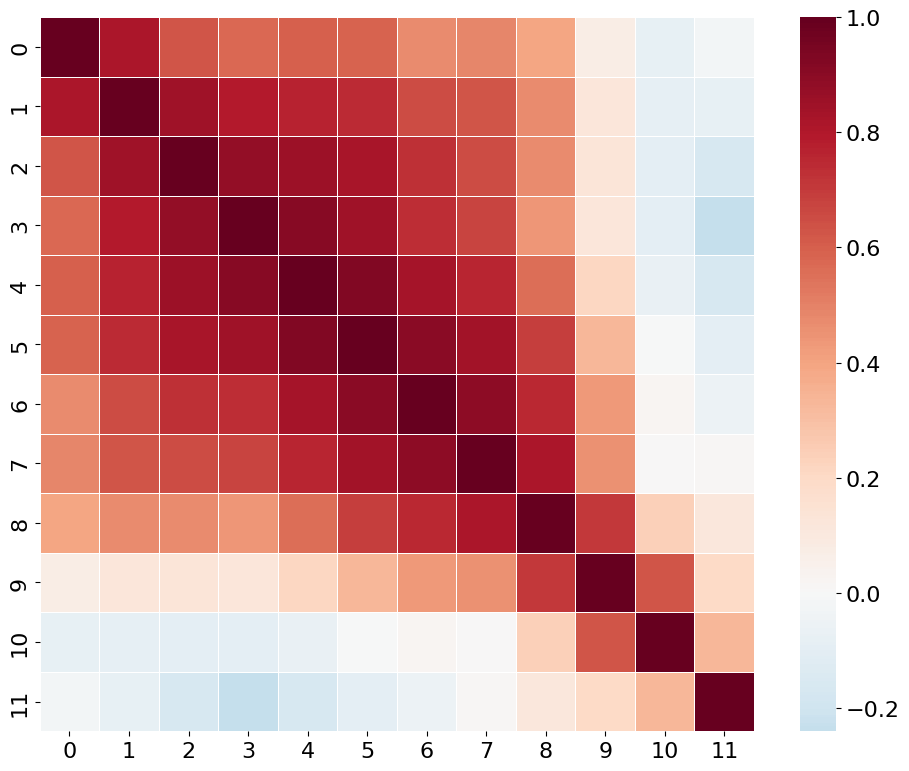

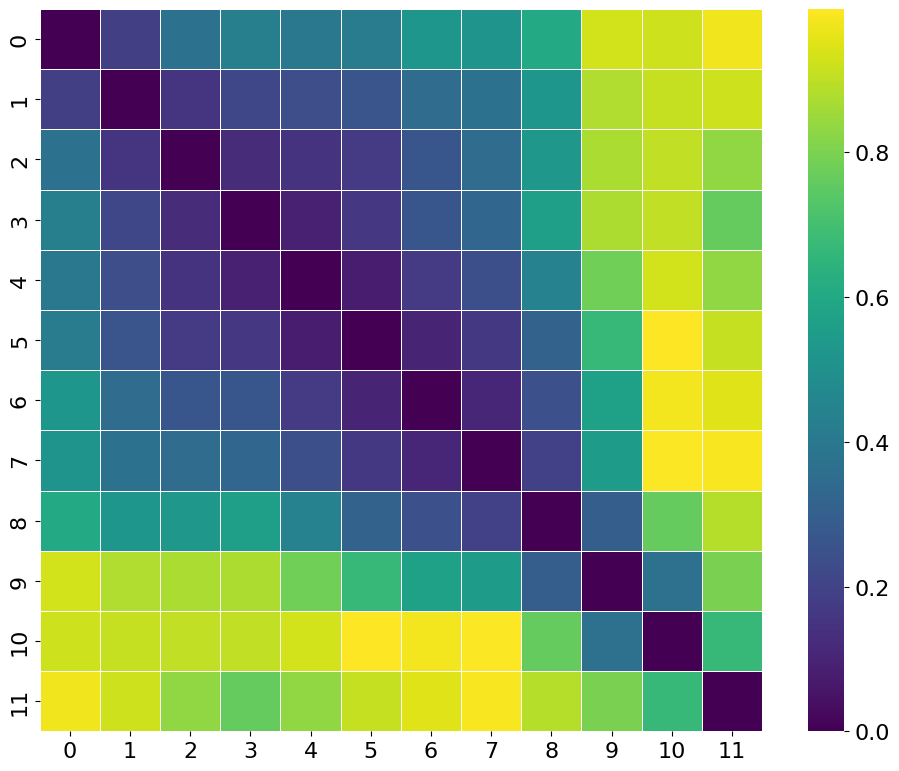

In [26]:
# 绘制相关性热力图 - 分别保存为矢量图
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局字体大小
plt.rcParams.update({'font.size': 16})

# 相关性矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            fmt='.3f',
            square=True,
            linewidths=0.5,
            center=0)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('pics/layer_correlation_matrix.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

# 距离矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix, 
            annot=False, 
            cmap='viridis', 
            fmt='.3f',
            square=True,
            linewidths=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('pics/layer_distance_matrix.eps', format='eps', dpi=300, bbox_inches='tight')
plt.show()

# 恢复默认字体设置
plt.rcParams.update(plt.rcParamsDefault)